# KdV evolution of `-v sech^2(x)`

This notebook is independent from the ISTM notebook. It uses the reusable Fourier ETDRK4 KdV code in `NumISTNext/src/kdv/spectral_etdrk4.jl` to evolve the one-hump potential

$$q(x,0)=-v\operatorname{sech}^2(x), \qquad 0\le t\le 5.$$

It writes a GIF animation, a heatmap, and a small summary table under `NumISTNext/output/sech2_evolution/`. The checked time stepper stops a run if invariant drift or non-finite values exceed the configured tolerances.

In [1]:
using Pkg

function find_numistnext_root(start=pwd())
    dir = abspath(start)
    while true
        candidates = (dir, joinpath(dir, "NumISTNext"))
        for cand in candidates
            if isfile(joinpath(cand, "src", "NumISTNext.jl")) && isfile(joinpath(cand, "scripts", "Project.toml"))
                return cand
            end
        end
        parent = dirname(dir)
        parent == dir && error("Could not find NumISTNext from $start")
        dir = parent
    end
end

project_root = find_numistnext_root(@__DIR__)
Pkg.activate(joinpath(project_root, "scripts"))
Pkg.instantiate()

include(joinpath(project_root, "src", "NumISTNext.jl"))
# Keep an explicit module handle. In notebooks, re-running cells can leave
# imported names stale or ambiguous; qualified calls below are more robust.
NIST = Main.NumISTNext
using FFTW
using LinearAlgebra
using Printf
using Statistics
using Plots

gr()
default(framestyle=:box, linewidth=2, legend=:topright)

outdir = joinpath(project_root, "output", "sech2_evolution")
mkpath(outdir)
project_root, outdir

  Activating project at `~/Desktop/ResearchProjects/NumIST/NumISTNext/scripts`


("/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext", "/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext/output/sech2_evolution")

## Parameters and soliton-count heuristic

For the associated Pöschl-Teller spectral problem, `-v sech^2(x)` can be written as `-a(a+1) sech^2(x)` with

$$a=\frac{\sqrt{1+4v}-1}{2}.$$

The number of bound states, hence the expected number of soliton components in the KdV decomposition, is `ceil(a)` for `v>0`. The notebook uses this as a diagnostic for how changing `v` changes the soliton count.

In [2]:
sech(x) = inv(cosh(x))
sech2_profile(x, v) = -v * sech(x)^2

pt_parameter(v) = (sqrt(1 + 4v) - 1) / 2

function predicted_soliton_count(v)
    v <= 0 && return 0
    return max(0, ceil(Int, pt_parameter(v) - 100eps(Float64)))
end

function bound_state_kappas(v)
    a = pt_parameter(v)
    nsol = predicted_soliton_count(v)
    return [a - j for j in 0:nsol-1 if a - j > 100eps(Float64)]
end

v_slug(v) = replace(@sprintf("%.3g", Float64(v)), "." => "p", "-" => "m")

# Main stable comparison set. The optional v=12 stress case below is expected
# to stop on this grid because the invariant drift becomes too large.
v_values = [0.5, 12.0, 6.0]
selected_v = 12

tmax = 5.0
save_dt = 0.05
dt = 0.001
L = 160.0
nx = 8192
xgrid = collect(range(-L, L; length=nx + 1))[1:end-1]

[(v=v, a=pt_parameter(v), count=predicted_soliton_count(v), kappas=bound_state_kappas(v)) for v in v_values]

3-element Vector{@NamedTuple{v::Float64, a::Float64, count::Int64, kappas::Vector{Float64}}}:
 (v = 0.5, a = 0.3660254037844386, count = 1, kappas = [0.3660254037844386])
 (v = 12.0, a = 3.0, count = 3, kappas = [3.0, 2.0, 1.0])
 (v = 6.0, a = 2.0, count = 2, kappas = [2.0, 1.0])

## Checked ETDRK4 time evolution

The function below mirrors `solve_kdv_etdrk4`, but saves a dense time history for plotting and checks stability at every saved frame. The error monitor uses relative mass drift, relative squared-L2 drift, a finite-value check, and a maximum-amplitude guard.

In [3]:
function evolve_kdv_checked(q0, xgrid; tmax=5.0, dt=0.001, save_dt=0.05,
                            mass_rel_tol=1e-5, l2_rel_tol=2e-3,
                            maxabs_factor=6.0, dealias=true)
    n = length(xgrid)
    n == length(q0) || throw(ArgumentError("q0 and xgrid must have equal length"))
    iseven(n) || throw(ArgumentError("xgrid length must be even"))
    dx = xgrid[2] - xgrid[1]
    period = n * dx
    k = NIST.fourier_wavenumbers(n, period)
    _, E, E2, Q, f1, f2, f3 = NIST.etdrk4_coefficients(k, dt)
    mask = dealias ? abs.(k) .<= (2 / 3) * maximum(abs.(k)) : trues(n)

    save_every = max(1, round(Int, save_dt / dt))
    nsteps = round(Int, tmax / dt)
    abs(save_every * dt - save_dt) < 100eps(Float64) || error("save_dt must be an integer multiple of dt")
    abs(nsteps * dt - tmax) < 100eps(Float64) || error("tmax must be an integer multiple of dt")

    function nonlinear(vhat)
        u = real.(ifft(vhat))
        nhat = 3im .* k .* fft(u.^2)
        nhat .*= mask
        return nhat
    end

    profiles = Vector{Vector{Float64}}()
    times = Float64[]
    diagnostics = Any[]
    inv0 = NIST.sampled_invariants(xgrid, q0)
    maxabs_limit = maxabs_factor * maximum(abs, q0) + 1

    function save_frame!(t, u)
        invs = NIST.sampled_invariants(xgrid, u)
        mass_rel = abs(invs.mass - inv0.mass) / max(abs(inv0.mass), eps(Float64))
        l2_rel = abs(invs.l2 - inv0.l2) / max(abs(inv0.l2), eps(Float64))
        maxabs = maximum(abs, u)
        finite = all(isfinite, u)
        row = (; time=t, invs.mass, mass_rel, invs.l2, l2_rel, maxabs, finite)
        push!(times, t)
        push!(profiles, Float64.(u))
        push!(diagnostics, row)
        return row
    end

    vhat = fft(q0)
    stopped = false
    stop_reason = "completed"
    save_frame!(0.0, Float64.(q0))

    for step in 1:nsteps
        Nv = nonlinear(vhat)
        a = E2 .* vhat .+ Q .* Nv
        Na = nonlinear(a)
        b = E2 .* vhat .+ Q .* Na
        Nb = nonlinear(b)
        c = E2 .* a .+ Q .* (2 .* Nb .- Nv)
        Nc = nonlinear(c)
        vhat = E .* vhat .+ f1 .* Nv .+ 2 .* f2 .* (Na .+ Nb) .+ f3 .* Nc
        vhat .*= mask

        if step % save_every == 0 || step == nsteps
            row = save_frame!(step * dt, real.(ifft(vhat)))
            if !row.finite
                stopped = true
                stop_reason = @sprintf("non-finite values at t=%.3f", row.time)
                break
            elseif row.mass_rel > mass_rel_tol
                stopped = true
                stop_reason = @sprintf("mass drift %.3e exceeded %.3e at t=%.3f", row.mass_rel, mass_rel_tol, row.time)
                break
            elseif row.l2_rel > l2_rel_tol
                stopped = true
                stop_reason = @sprintf("L2 drift %.3e exceeded %.3e at t=%.3f", row.l2_rel, l2_rel_tol, row.time)
                break
            elseif row.maxabs > maxabs_limit
                stopped = true
                stop_reason = @sprintf("max |q| %.3e exceeded %.3e at t=%.3f", row.maxabs, maxabs_limit, row.time)
                break
            end
        end
    end

    U = Matrix{Float64}(undef, length(profiles), n)
    for i in eachindex(profiles)
        U[i, :] .= profiles[i]
    end
    return (; x=xgrid, times, u=U, diagnostics, stopped, stop_reason)
end

evolve_kdv_checked (generic function with 1 method)

In [4]:
runs = Dict{Float64, Any}()

function run_for_v!(runs, v)
    vf = Float64(v)
    if !haskey(runs, vf)
        q0 = sech2_profile.(xgrid, vf)
        runs[vf] = evolve_kdv_checked(q0, xgrid; tmax=tmax, dt=dt, save_dt=save_dt)
    end
    return runs[vf]
end

for v in v_values
    run = run_for_v!(runs, v)
    lastdiag = run.diagnostics[end]
    @printf("v=%4.1f  predicted solitons=%d  frames=%d  stopped=%s  max L2 drift=%9.3e\n",
            v, predicted_soliton_count(v), length(run.times), string(run.stopped),
            maximum(row.l2_rel for row in run.diagnostics))
    @printf("        final t=%5.2f  max |q|=%8.4f  reason=%s\n",
            lastdiag.time, lastdiag.maxabs, run.stop_reason)
end

v= 0.5  predicted solitons=1  frames=101  stopped=false  max L2 drift=7.661e-13
        final t= 5.00  max |q|=  0.2888  reason=completed
v=12.0  predicted solitons=3  frames=3  stopped=true  max L2 drift=2.413e-03
        final t= 0.10  max |q|= 17.9255  reason=L2 drift 2.413e-03 exceeded 2.000e-03 at t=0.100
v= 6.0  predicted solitons=2  frames=101  stopped=false  max L2 drift=3.283e-04
        final t= 5.00  max |q|=  7.9956  reason=completed


## Stability tests

The `v=2` case is an exact one-soliton: `-2 sech^2(x-4t)`. The first assertion checks the numerical solution against that exact profile. The second checks invariant drift on the default runs. The stress test with `v=12` verifies that the stop condition catches a run whose grid/timestep is not accurate enough.

In [5]:
exact_v2(x, t) = -2 * sech(x - 4t)^2
run2 = run_for_v!(runs, 2.0)
exact_errors = [maximum(abs.(run2.u[i, :] .- exact_v2.(run2.x, t))) for (i, t) in enumerate(run2.times)]
max_exact_error = maximum(exact_errors)
completed_runs = [run for run in values(runs) if !run.stopped]
max_completed_l2_drift = isempty(completed_runs) ? NaN : maximum(row.l2_rel for run in completed_runs for row in run.diagnostics)

stress_v = 12.0
stress_run = run_for_v!(runs, stress_v)

@assert max_exact_error < 1e-5
@assert isnan(max_completed_l2_drift) || max_completed_l2_drift < 2e-3
@assert stress_run.stopped

(; max_exact_error, max_completed_l2_drift, stress_stop_time=stress_run.times[end], stress_reason=stress_run.stop_reason)

(max_exact_error = 4.9270623803110425e-8, max_completed_l2_drift = 0.00032834403756417285, stress_stop_time = 0.1, stress_reason = "L2 drift 2.413e-03 exceeded 2.000e-03 at t=0.100")

## How `v` changes the number of solitons

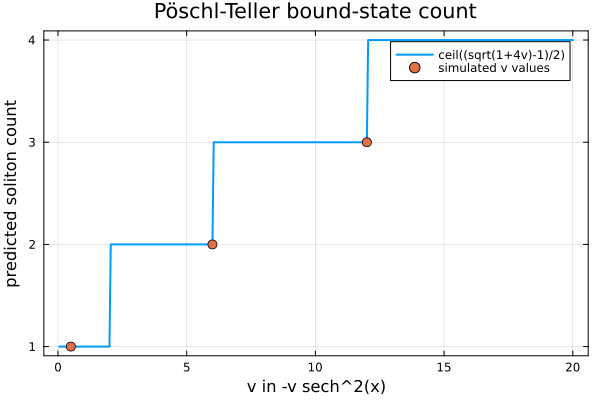

In [6]:
v_scan = collect(range(0.05, 20.0; length=400))
count_scan = predicted_soliton_count.(v_scan)
count_plot = plot(v_scan, count_scan;
    xlabel="v in -v sech^2(x)", ylabel="predicted soliton count",
    label="ceil((sqrt(1+4v)-1)/2)", yticks=0:5,
    title="Pöschl-Teller bound-state count")
scatter!(count_plot, v_values, predicted_soliton_count.(v_values);
    label="simulated v values", markersize=5)
count_path = joinpath(outdir, "sech2_soliton_count_vs_v.png")
savefig(count_plot, count_path)
count_plot

## Heatmap for the selected one-hump evolution

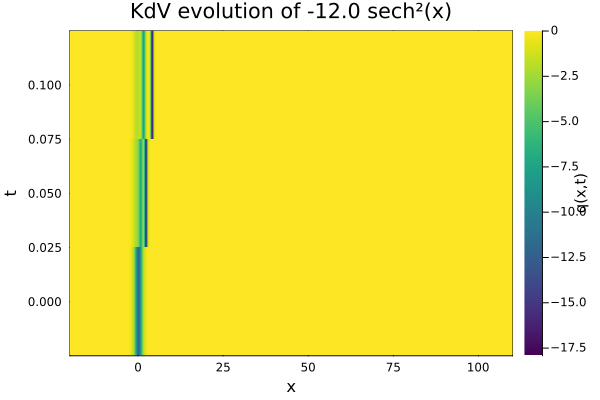

In [7]:
selected_v_float = Float64(selected_v)
selected = run_for_v!(runs, selected_v_float)
x_window = (-20.0, 110.0)
heatmap_plot = heatmap(selected.x, selected.times, selected.u;
    xlabel="x", ylabel="t", xlims=x_window,
    color=:viridis, title="KdV evolution of -$(selected_v_float) sech²(x)",
    colorbar_title="q(x,t)")
heatmap_path = joinpath(outdir, "sech2_v$(v_slug(selected_v_float))_heatmap.png")
savefig(heatmap_plot, heatmap_path)
heatmap_plot

## GIF animation

In [8]:
gif_path = joinpath(outdir, "sech2_v$(v_slug(selected_v_float))_evolution.gif")
umin = minimum(selected.u)
umax = maximum(selected.u)
ypad = 0.08 * max(abs(umin), abs(umax), 1.0)

anim = @animate for (i, t) in enumerate(selected.times)
    plot(selected.x, selected.u[i, :];
        xlims=x_window, ylims=(umin - ypad, umax + ypad),
        xlabel="x", ylabel="q(x,t)", label=false,
        title=@sprintf("-%.1f sech²(x),  t = %.2f", selected_v_float, t),
        color=:black)
end every 2

gif(anim, gif_path; fps=15)
gif_path

[ Info: Saved animation to /Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext/output/sech2_evolution/sech2_v12_evolution.gif


"/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext/output/sech2_evolution/sech2_v12_evolution.gif"

## Write a compact text summary

In [9]:
summary_path = joinpath(outdir, "sech2_evolution_summary.txt")
open(summary_path, "w") do io
    println(io, "KdV evolution of q(x,0)=-v sech^2(x)")
    println(io, "domain=[", first(xgrid), ", ", last(xgrid), "], nx=", nx, ", dt=", dt, ", tmax=", tmax)
    println(io, "")
    for v in v_values
        run = run_for_v!(runs, v)
        println(io, "v=", v,
            " predicted_count=", predicted_soliton_count(v),
            " kappas=", bound_state_kappas(v),
            " stopped=", run.stopped,
            " stop_reason=", run.stop_reason,
            " max_l2_rel=", maximum(row.l2_rel for row in run.diagnostics))
    end
    println(io, "")
    println(io, "v=2 exact one-soliton max error=", max_exact_error)
    println(io, "stress v=", stress_v, " stopped=", stress_run.stopped, " at t=", stress_run.times[end])
    println(io, "stress reason=", stress_run.stop_reason)
end

(; notebook=@__FILE__, count_path, heatmap_path, gif_path, summary_path)

(notebook = "In[9]", count_path = "/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext/output/sech2_evolution/sech2_soliton_count_vs_v.png", heatmap_path = "/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext/output/sech2_evolution/sech2_v12_heatmap.png", gif_path = "/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext/output/sech2_evolution/sech2_v12_evolution.gif", summary_path = "/Users/fudong/Desktop/ResearchProjects/NumIST/NumISTNext/output/sech2_evolution/sech2_evolution_summary.txt")